In [348]:
#forces us to reload the libraries each time we do a function call,
#so I can update things in real time
%load_ext autoreload
%autoreload 2
#import path libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from utils import psf
from utils import plotting
from utils import zernike
from optimization import reconstruction
from tqdm import tqdm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [349]:
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

In [350]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05
L_ffp = 0.0065             # FFP size [mm]
grid_ffp = 64
grid_bfp = 64

In [351]:
microscope = psf.Microscope(N_order = N_order,
                            lambd = lambd,
                            n = n,
                            num_apt = num_apt,
                            f = f,
                            mag = mag,
                            w_0 = w_0,
                            L_bfp = L_bfp,
                            grid_bfp = grid_bfp)

grid = psf.Centered_Square_Grid(L_ffp = L_ffp,
                                grid_ffp = grid_ffp,
                                z_level = 0)

xs, ys = grid.get_xy()


modes = [[-2,2],
         [2,2],
         [-3,3],
         [-1,3],
         [1,3],
         [3,3],
         [0,4],
         [-4,4],
         [-2,4],
         [2,4],
         [4,4],
         [-5,5],
         [-3, 5],
         [-1, 5],
         [1, 5],
         [3, 5],
         [5,5]]

# modes = [[0,4]]

# fig, axs = plt.subplots(5, 5, dpi = 300)
# for i in range(5):
#     for j in range(5):

#         underlying_strengths = np.random.normal(0, 1, len(modes))

#         aberration = zernike.RMSAberration(modes = modes,
#                                 raw_strengths = underlying_strengths,
#                                 RMS_desired = 0.05 + 0.05 * j,
#                                 alpha = microscope.alpha)
        
#         _, axs[i,j] = plotting.zernike_plot(aberration.construct_map(microscope.alpha), microscope.alpha, ax = axs[i,j],
#                                             show = False, colorbar = False)


In [352]:
DIVERSITY_MODE = [0, 4]
DIVERSITY_STRENGTHS = np.array([-0.05, 0.0, 0.05])  # Coefficients in waves.
EXPERIMENT_SNR = 20.0


def acquire_diverse_images(image, aberration, focal_z_levels,
                           diversity_strengths=None, diversity_mode=None):
    # Known diversity frames at each measured z-plane.
    strengths = np.asarray(
        DIVERSITY_STRENGTHS if diversity_strengths is None else diversity_strengths,
        dtype=float,
    )
    if strengths.ndim != 1 or len(strengths) == 0 or not np.all(np.isfinite(strengths)):
        raise ValueError("Diversity strengths must be a nonempty finite vector.")
    known_mode = DIVERSITY_MODE if diversity_mode is None else diversity_mode
    positions = np.asarray(focal_z_levels, dtype=float)
    focal_z = np.repeat(positions, len(strengths))
    diversities = [
        zernike.Aberration([known_mode], [strength])
        for _ in positions for strength in strengths
    ]
    _, _, _, images = microscope.compute_image_3D(
        image=image, aberration=aberration, focal_z_levels=focal_z,
        diversities=diversities, mode="vector",
    )
    return focal_z, diversities, images


def aberration_loss_ratio(images, aberration, rho, grid, focal_z_levels,
                          sample_z_levels, diversities=None):
    """Compare profiled regularized losses on identical measurements and grids."""
    common = dict(
        microscope=microscope, grid=grid, images=images,
        focal_z_levels=focal_z_levels, sample_z_levels=sample_z_levels,
        rho=rho, diversities=diversities, mode="vector",
    )
    truth_loss = reconstruction.evaluate_loss_3D(aberration=aberration, **common)
    zero_loss = reconstruction.evaluate_loss_3D(
        aberration=zernike.EmptyAberration(aberration.modes), **common,
    )
    if zero_loss <= 0 or not np.isfinite(zero_loss) or not np.isfinite(truth_loss):
        raise ValueError("Loss ratio requires finite losses and positive loss at zero.")
    return truth_loss / zero_loss





def poisson_images_at_snr(clean_images, snr, rng):
    """Add Poisson noise at expected global RMS SNR, retaining intensity units."""
    clean_images = np.asarray(clean_images, dtype=float)
    if not np.isfinite(snr) or snr <= 0:
        raise ValueError("SNR must be finite and positive.")
    if not np.all(np.isfinite(clean_images)) or clean_images.max() <= 0:
        raise ValueError("Images must be finite with positive signal.")
    peak = clean_images.max()
    if clean_images.min() < -1e-12 * peak:
        raise ValueError("Images must be nonnegative.")
    unit_images = np.clip(clean_images / peak, 0, None)
    photon_scale = snr**2 * unit_images.sum() / np.sum(unit_images**2)
    counts = rng.poisson(photon_scale * unit_images)
    return (counts / photon_scale) * peak


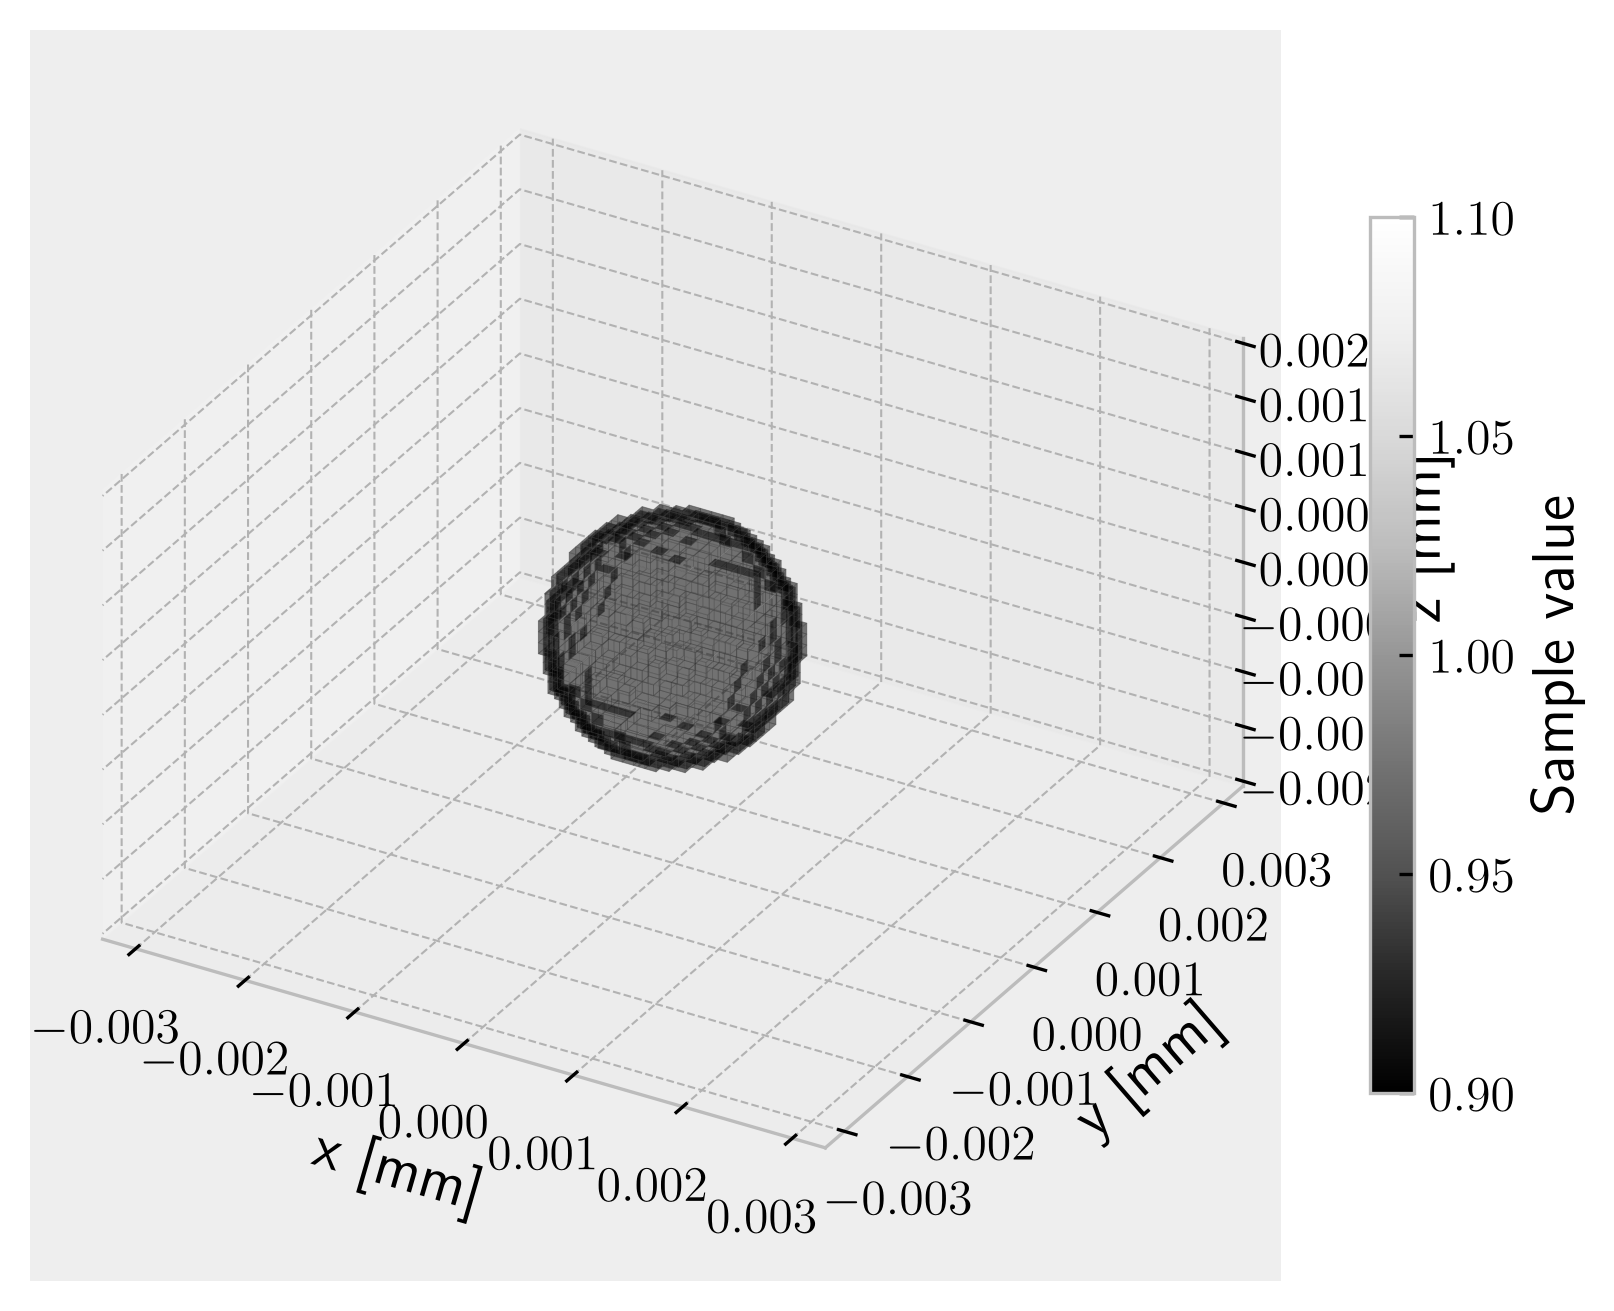

In [353]:
NUM_IMAGES = 8  # Measured z-planes; three diversity images per plane.

eps = 1e-10
z_sample_levels = np.arange(-0.002, 0.002 + eps, 0.0001)
z_image_levels = np.arange(-0.002, 0.002 + eps, (0.004 - eps) / (NUM_IMAGES - 1))

mask_3D = psf.bead_img_3D(grid = grid,
                            xs = [0.0],
                            ys = [0.0],
                            zs = [0.0],
                            bead_sizes = [0.001],
                            z_levels = z_sample_levels)

# mask_3D = psf.random_bead_img_3D(grid = grid,
#                                  z_levels = z_sample_levels,
#                                  num_beads = 5,
#                                  bead_size = 0.001)

fig, ax = plotting.plot_sample_3D(mask_3D, show=False)
fig.savefig("sample_3D.png", bbox_inches="tight")
plt.show()


In [354]:
rms_pattern_rng = np.random.default_rng(0)
rms_noise_rng = np.random.default_rng(1)
rms_raw_strengths = rms_pattern_rng.normal(0, 1, len(modes))
rms_grid = np.linspace(0, 0.3, 10)
rms_rho_grid = np.logspace(30, 60, 10)
rms_ratio_grid = np.empty((len(rms_grid), len(rms_rho_grid)))

with tqdm(total=rms_ratio_grid.size, desc="RMS scan") as progress:
    for i, rms in enumerate(rms_grid):
        rms_aberration = zernike.RMSAberration(
            modes=modes,
            raw_strengths=rms_raw_strengths,
            RMS_desired=rms,
            alpha=microscope.alpha,
        )
        rms_focal_z, rms_diversities, rms_clean_images = acquire_diverse_images(
            image=mask_3D,
            aberration=rms_aberration,
            focal_z_levels=z_image_levels,
        )

        rms_noisy_images = poisson_images_at_snr(
            rms_clean_images, EXPERIMENT_SNR, rms_noise_rng,
        )

        for j, rho in enumerate(rms_rho_grid):
            rms_ratio_grid[i, j] = aberration_loss_ratio(
                grid=grid,
                images=rms_noisy_images,
                focal_z_levels=rms_focal_z,
                diversities=rms_diversities,
                sample_z_levels=z_sample_levels,
                aberration=rms_aberration,
                rho=rho,
            )
            progress.update(1)


RMS scan: 100%|██████████| 100/100 [03:42<00:00,  2.23s/it]


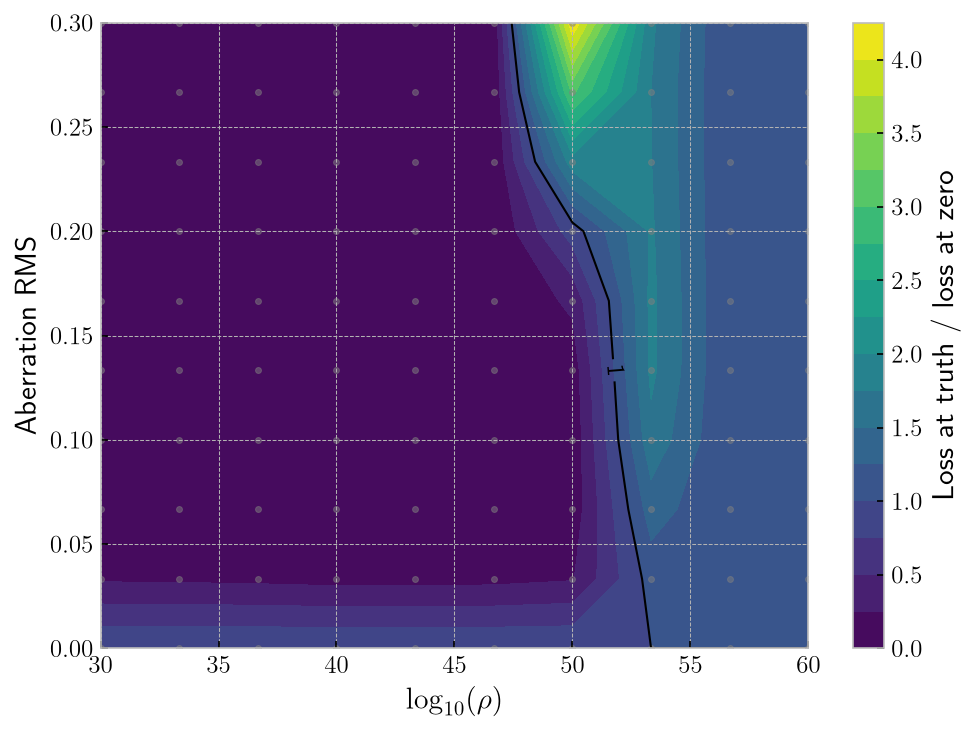

In [355]:
fig, ax = plt.subplots(dpi=150)
contours = ax.contourf(
    np.log10(rms_rho_grid), rms_grid,
    rms_ratio_grid,
    levels=20, cmap="viridis",
)
if rms_ratio_grid.min() < 1 < rms_ratio_grid.max():
    boundary = ax.contour(
        np.log10(rms_rho_grid), rms_grid, rms_ratio_grid,
        levels=[1], colors="black", linewidths=1,
    )
    ax.clabel(boundary, fmt="%g")
sampled_x, sampled_y = np.meshgrid(np.log10(rms_rho_grid), rms_grid)
ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)

ax.set_xlabel(r"$\log_{10}(\rho)$")
ax.set_ylabel(r"Aberration RMS")
fig.colorbar(contours, ax=ax, label="Loss at truth / loss at zero")
fig.savefig("rho_aberration_rms.png", bbox_inches="tight")
plt.show()


In [356]:
# Fixed RMS 0.1; pure Poisson noise; average loss ratio over independent trials.
poisson_pattern_rng = np.random.default_rng(0)
poisson_noise_rng = np.random.default_rng(1)
poisson_aberration = zernike.RMSAberration(
    modes=modes,
    raw_strengths=poisson_pattern_rng.normal(0, 1, len(modes)),
    RMS_desired=0.1,
    alpha=microscope.alpha,
)
poisson_focal_z, poisson_diversities, poisson_clean_images = acquire_diverse_images(
    image=mask_3D,
    aberration=poisson_aberration,
    focal_z_levels=z_image_levels,
)
poisson_clean_images = np.asarray(poisson_clean_images, dtype=float)
if not np.all(np.isfinite(poisson_clean_images)) or poisson_clean_images.max() <= 0:
    raise ValueError("Poisson simulation requires finite images with positive signal.")
# Allow only negligible negative roundoff in the simulated intensities.
poisson_peak = poisson_clean_images.max()
if poisson_clean_images.min() < -1e-12 * poisson_peak:
    raise ValueError("Poisson simulation requires nonnegative intensities.")
poisson_unit_images = np.clip(poisson_clean_images / poisson_peak, 0, None)

poisson_snr_grid = np.logspace(0, 2, 10)
poisson_rho_grid = np.logspace(30, 60, 10)
poisson_trials = 3
poisson_photon_scales = (
    poisson_snr_grid**2
    * poisson_unit_images.sum()
    / np.sum(poisson_unit_images**2)
)
poisson_expected_total_counts = poisson_photon_scales * poisson_unit_images.sum()
poisson_trial_ratios = np.empty(
    (len(poisson_snr_grid), len(poisson_rho_grid), poisson_trials)
)

poisson_example_images = np.empty(
    (len(poisson_snr_grid),) + poisson_clean_images.shape
)

with tqdm(total=poisson_trial_ratios.size, desc="Poisson SNR scan") as progress:
    for i, photon_scale in enumerate(poisson_photon_scales):
        for trial in range(poisson_trials):
            counts = poisson_noise_rng.poisson(photon_scale * poisson_unit_images)
            noisy_images = (counts / photon_scale) * poisson_peak
            if trial == 0:
                poisson_example_images[i] = noisy_images
            for j, rho in enumerate(poisson_rho_grid):
                poisson_trial_ratios[i, j, trial] = aberration_loss_ratio(
                    grid=grid,
                    images=noisy_images,
                    focal_z_levels=poisson_focal_z,
                    diversities=poisson_diversities,
                    sample_z_levels=z_sample_levels,
                    aberration=poisson_aberration,
                    rho=rho,
                )
                progress.update(1)

poisson_ratio_grid = poisson_trial_ratios.mean(axis=2)
poisson_ratio_std_grid = poisson_trial_ratios.std(axis=2, ddof=1)


Poisson SNR scan: 100%|██████████| 300/300 [09:59<00:00,  2.00s/it]


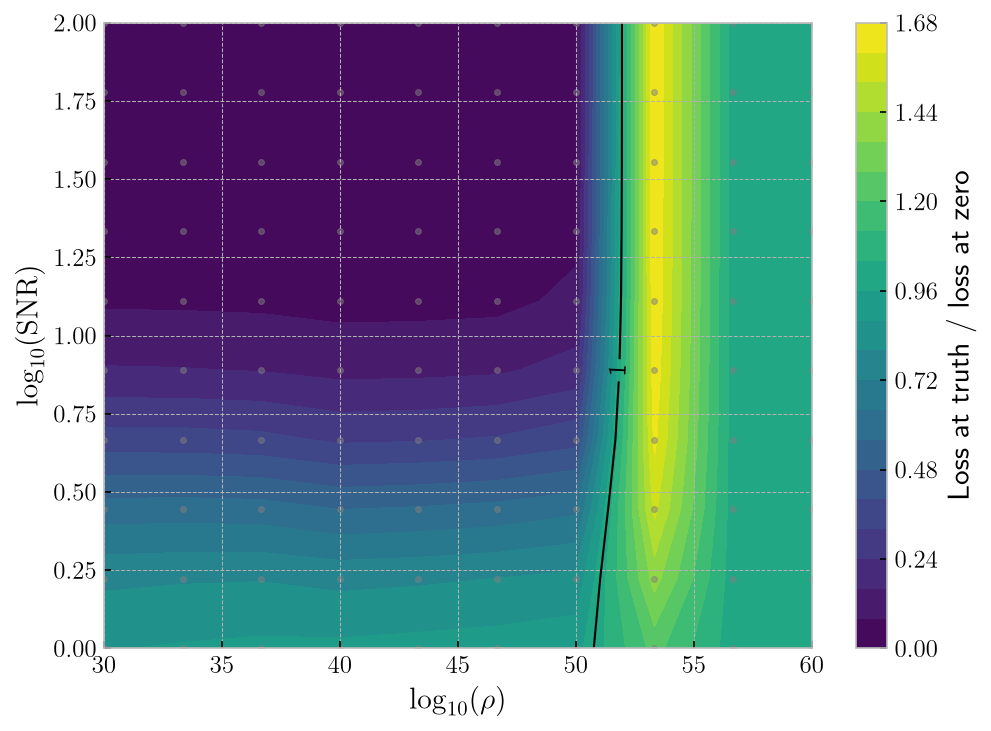

In [357]:
fig, ax = plt.subplots(dpi=150)
contours = ax.contourf(
    np.log10(poisson_rho_grid), np.log10(poisson_snr_grid),
    poisson_ratio_grid,
    levels=20, cmap="viridis",
)
if poisson_ratio_grid.min() < 1 < poisson_ratio_grid.max():
    boundary = ax.contour(
        np.log10(poisson_rho_grid), np.log10(poisson_snr_grid), poisson_ratio_grid,
        levels=[1], colors="black", linewidths=1,
    )
    ax.clabel(boundary, fmt="%g")
sampled_x, sampled_y = np.meshgrid(np.log10(poisson_rho_grid), np.log10(poisson_snr_grid))
ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)

ax.set_xlabel(r"$\log_{10}(\rho)$")
ax.set_ylabel(r"$\log_{10}(\mathrm{SNR})$")
fig.colorbar(contours, ax=ax, label="Loss at truth / loss at zero")
fig.savefig("rho_SNR.png", bbox_inches="tight")
plt.show()


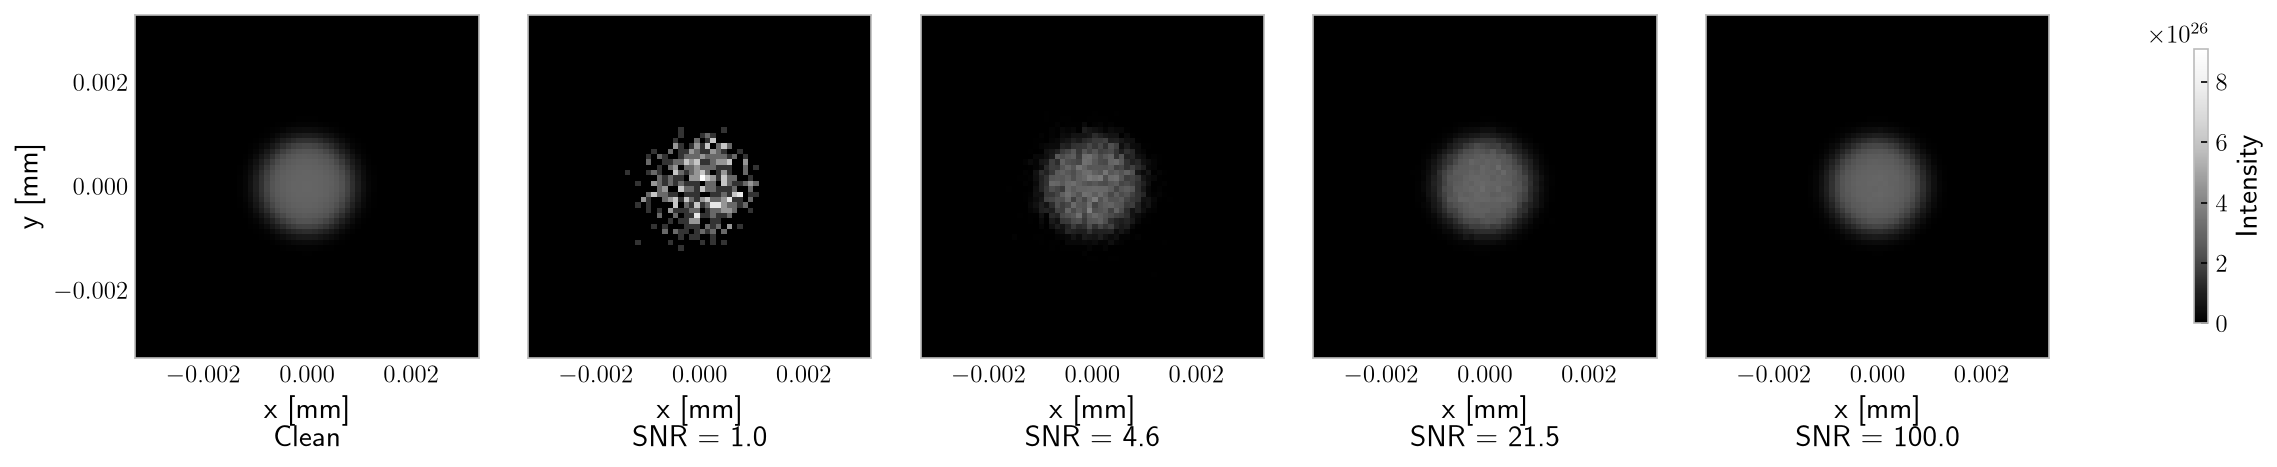

In [358]:
# Use the first noise realization saved by the scan.
poisson_example_indices = np.unique(
    np.linspace(0, len(poisson_snr_grid) - 1, 4, dtype=int)
)
poisson_example_plane = (
    len(DIVERSITY_STRENGTHS) * np.argmin(np.abs(z_image_levels))
    + np.argmin(np.abs(DIVERSITY_STRENGTHS))
)
poisson_examples = [poisson_clean_images[poisson_example_plane]] + [
    poisson_example_images[i, poisson_example_plane]
    for i in poisson_example_indices
]
poisson_example_labels = ["Clean"] + [
    f"SNR = {poisson_snr_grid[i]:.1f}" for i in poisson_example_indices
]
poisson_example_vmax = max(image.max() for image in poisson_examples)

fig, axs = plt.subplots(
    1, len(poisson_examples), figsize=(3 * len(poisson_examples), 3),
    dpi=150, sharex=True, sharey=True, layout="constrained",
)
for ax, image, label in zip(axs, poisson_examples, poisson_example_labels):
    artist = ax.imshow(
        image.T,
        extent=plotting._image_extent(xs, ys),
        origin="lower", aspect="equal", cmap="Greys_r",
        vmin=0, vmax=poisson_example_vmax,
    )
    ax.grid(False)
    ax.set_xlabel("x [mm]\n" + label)
axs[0].set_ylabel("y [mm]")
fig.colorbar(artist, ax=list(axs), label="Intensity", shrink=0.8)
fig.savefig("poisson_snr_examples.png", bbox_inches="tight")
plt.show()


In [359]:
image_count_pattern_rng = np.random.default_rng(0)
image_count_noise_rng = np.random.default_rng(1)
image_count_aberration = zernike.RMSAberration(
    modes=modes,
    raw_strengths=image_count_pattern_rng.normal(0, 1, len(modes)),
    RMS_desired=0.1,
    alpha=microscope.alpha,
)
image_count_grid = np.arange(2, 12)
image_count_rho_grid = np.logspace(30, 60, 10)
image_count_ratio_grid = np.empty((len(image_count_grid), len(image_count_rho_grid)))

with tqdm(total=image_count_ratio_grid.size, desc="Measured z-plane count scan") as progress:
    for i, image_count in enumerate(image_count_grid):
        image_count_z_levels = np.linspace(
            z_image_levels.min(), z_image_levels.max(), image_count,
        )
        image_count_focal_z, image_count_diversities, image_count_clean_images = acquire_diverse_images(
            image=mask_3D,
            aberration=image_count_aberration,
            focal_z_levels=image_count_z_levels,
        )

        image_count_noisy_images = poisson_images_at_snr(
            image_count_clean_images, EXPERIMENT_SNR, image_count_noise_rng,
        )

        for j, rho in enumerate(image_count_rho_grid):
            image_count_ratio_grid[i, j] = aberration_loss_ratio(
                grid=grid,
                images=image_count_noisy_images,
                focal_z_levels=image_count_focal_z,
                diversities=image_count_diversities,
                sample_z_levels=z_sample_levels,
                aberration=image_count_aberration,
                rho=rho,
            )
            progress.update(1)


Measured z-plane count scan: 100%|██████████| 100/100 [03:00<00:00,  1.80s/it]


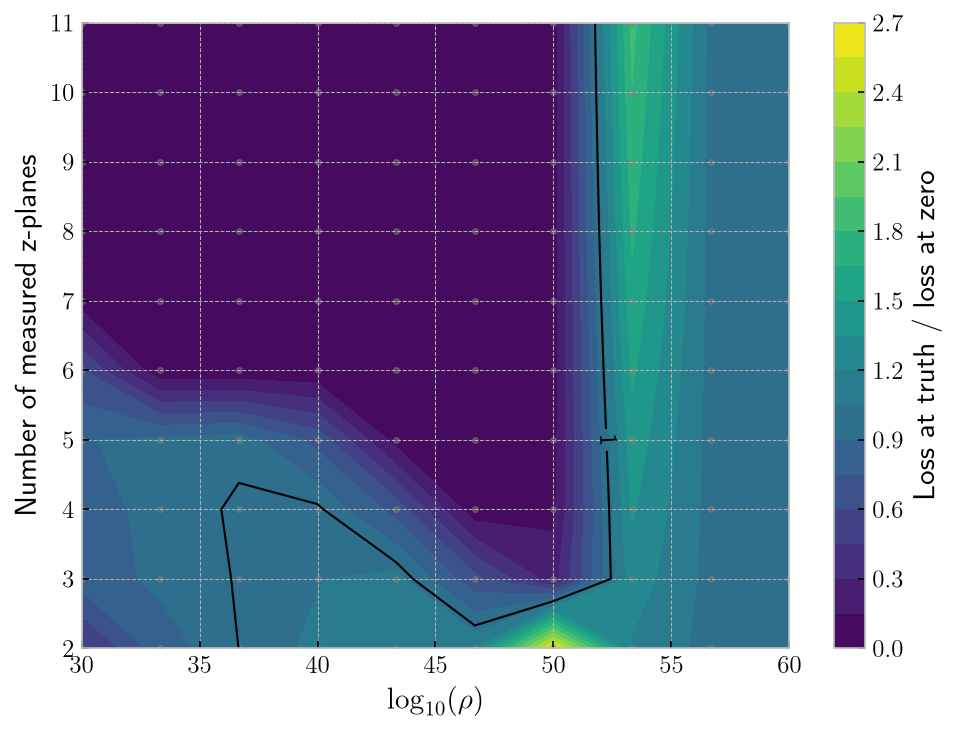

In [360]:
fig, ax = plt.subplots(dpi=150)
contours = ax.contourf(
    np.log10(image_count_rho_grid), image_count_grid,
    image_count_ratio_grid,
    levels=20, cmap="viridis",
)
if image_count_ratio_grid.min() < 1 < image_count_ratio_grid.max():
    boundary = ax.contour(
        np.log10(image_count_rho_grid), image_count_grid, image_count_ratio_grid,
        levels=[1], colors="black", linewidths=1,
    )
    ax.clabel(boundary, fmt="%g")
sampled_x, sampled_y = np.meshgrid(np.log10(image_count_rho_grid), image_count_grid)
ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)

ax.set_xlabel(r"$\log_{10}(\rho)$")
ax.set_ylabel("Number of measured z-planes")
ax.set_yticks(image_count_grid)
fig.colorbar(contours, ax=ax, label="Loss at truth / loss at zero")
fig.savefig("rho_imagenumber.png", bbox_inches="tight")
plt.show()


In [361]:
plane_count_pattern_rng = np.random.default_rng(0)
plane_count_noise_rng = np.random.default_rng(1)
plane_count_aberration = zernike.RMSAberration(
    modes=modes,
    raw_strengths=plane_count_pattern_rng.normal(0, 1, len(modes)),
    RMS_desired=0.1,
    alpha=microscope.alpha,
)
plane_count_focal_z, plane_count_diversities, plane_count_clean_images = acquire_diverse_images(
    image=mask_3D,
    aberration=plane_count_aberration,
    focal_z_levels=z_image_levels,
)

plane_count_noisy_images = poisson_images_at_snr(
    plane_count_clean_images, EXPERIMENT_SNR, plane_count_noise_rng,
)

plane_count_grid = np.arange(5, 84, 4)
plane_count_rho_grid = np.logspace(30, 60, 10)
plane_count_ratio_grid = np.empty((len(plane_count_grid), len(plane_count_rho_grid)))

with tqdm(total=plane_count_ratio_grid.size, desc="Reconstructed plane count scan") as progress:
    for i, plane_count in enumerate(plane_count_grid):
        plane_count_z_levels = np.linspace(
            z_sample_levels.min(), z_sample_levels.max(), plane_count,
        )
        for j, rho in enumerate(plane_count_rho_grid):
            plane_count_ratio_grid[i, j] = aberration_loss_ratio(
                grid=grid,
                images=plane_count_noisy_images,
                focal_z_levels=plane_count_focal_z,
                diversities=plane_count_diversities,
                sample_z_levels=plane_count_z_levels,
                aberration=plane_count_aberration,
                rho=rho,
            )
            progress.update(1)


Reconstructed plane count scan: 100%|██████████| 200/200 [06:45<00:00,  2.03s/it]


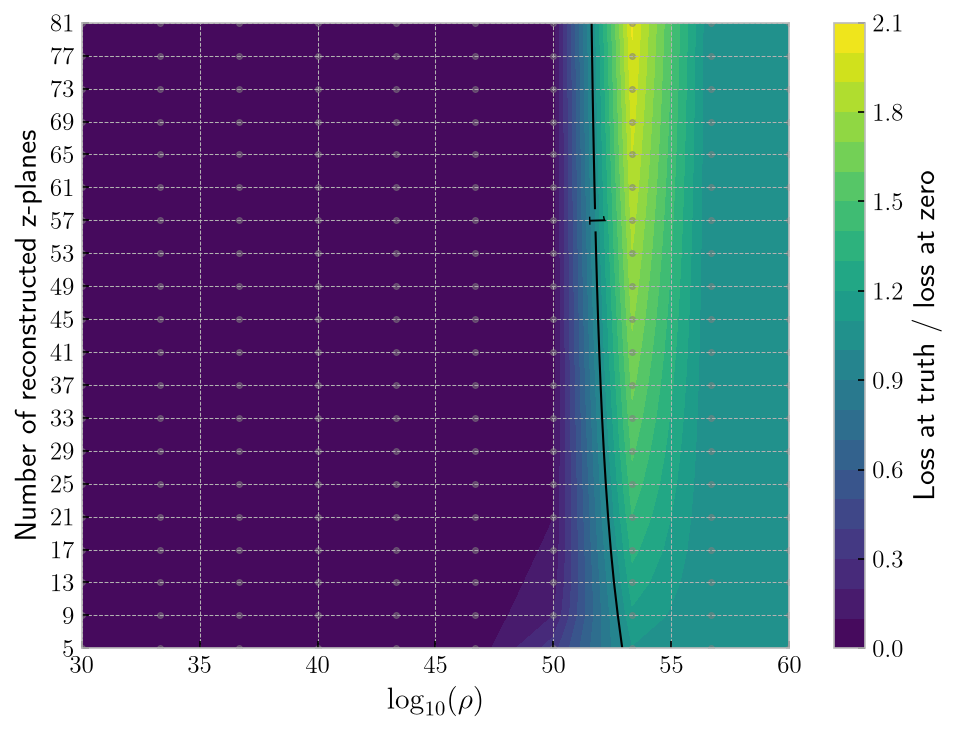

In [362]:
fig, ax = plt.subplots(dpi=150)
contours = ax.contourf(
    np.log10(plane_count_rho_grid), plane_count_grid,
    plane_count_ratio_grid,
    levels=20, cmap="viridis",
)
if plane_count_ratio_grid.min() < 1 < plane_count_ratio_grid.max():
    boundary = ax.contour(
        np.log10(plane_count_rho_grid), plane_count_grid, plane_count_ratio_grid,
        levels=[1], colors="black", linewidths=1,
    )
    ax.clabel(boundary, fmt="%g")
sampled_x, sampled_y = np.meshgrid(np.log10(plane_count_rho_grid), plane_count_grid)
ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)

ax.set_xlabel(r"$\log_{10}(\rho)$")
ax.set_ylabel("Number of reconstructed z-planes")
ax.set_yticks(plane_count_grid)
fig.colorbar(contours, ax=ax, label="Loss at truth / loss at zero")
fig.savefig("rho_reconstructed_planes.png", bbox_inches="tight")
plt.show()


In [363]:
def centered_bead_at_occupancy(target_percent):
    """Choose the centered bead radius giving the nearest attainable voxel occupancy."""
    if not 0 < target_percent < 100:
        raise ValueError("Target occupancy must lie strictly between 0 and 100 percent.")
    sample_xs, sample_ys = grid.get_xy()
    # Sorting voxel distances accounts for sampling and clipping at the volume edges.
    distances = np.sqrt(
        z_sample_levels[:, None, None]**2
        + sample_xs[None, :, None]**2
        + sample_ys[None, None, :]**2
    )
    unique_distances, counts = np.unique(distances, return_counts=True)
    attainable_percent = 100 * np.cumsum(counts) / distances.size
    index = np.argmin(np.abs(attainable_percent - target_percent))
    # Include voxels on the sphere despite floating-point roundoff in cross-sections.
    radius = unique_distances[index] + 8 * np.finfo(float).eps * unique_distances[-1]
    sample = psf.bead_img_3D(
        grid=grid, z_levels=z_sample_levels,
        xs=[0.0], ys=[0.0], zs=[0.0], bead_sizes=[radius],
    )
    return sample, radius


# One centered bead; vary only radius. Fixed RMS, voxel brightness, and acquisition.
# Large beads are clipped by the existing sample volume; occupancy uses actual voxels.
occupancy_pattern_rng = np.random.default_rng(0)
occupancy_noise_rng = np.random.default_rng(1)
occupancy_aberration = zernike.RMSAberration(
    modes=modes,
    raw_strengths=occupancy_pattern_rng.normal(0, 1, len(modes)),
    RMS_desired=0.1,
    alpha=microscope.alpha,
)
occupancy_target_grid = np.linspace(1, 60, 10)  # Percent of all sample voxels filled.
occupancy_rho_grid = np.logspace(30, 60, 10)
occupancy_ratio_grid = np.empty((len(occupancy_target_grid), len(occupancy_rho_grid)))
occupancy_actual_percent = np.empty(len(occupancy_target_grid))
occupancy_bead_radii = np.empty(len(occupancy_target_grid))
occupancy_samples = []

with tqdm(total=occupancy_ratio_grid.size, desc="Centered bead occupancy scan") as progress:
    for i, target_percent in enumerate(occupancy_target_grid):
        occupancy_sample, radius = centered_bead_at_occupancy(target_percent)
        occupancy_truth = occupancy_sample.image_mask
        occupancy_actual_percent[i] = (
            100 * np.count_nonzero(occupancy_truth) / occupancy_truth.size
        )
        occupancy_bead_radii[i] = radius
        occupancy_samples.append(occupancy_sample)
        occupancy_focal_z, occupancy_diversities, occupancy_clean_images = acquire_diverse_images(
            image=occupancy_sample,
            aberration=occupancy_aberration,
            focal_z_levels=z_image_levels,
        )
        occupancy_noisy_images = poisson_images_at_snr(
            occupancy_clean_images, EXPERIMENT_SNR, occupancy_noise_rng,
        )

        for j, rho in enumerate(occupancy_rho_grid):
            occupancy_ratio_grid[i, j] = aberration_loss_ratio(
                grid=grid,
                images=occupancy_noisy_images,
                focal_z_levels=occupancy_focal_z,
                diversities=occupancy_diversities,
                sample_z_levels=z_sample_levels,
                aberration=occupancy_aberration,
                rho=rho,
            )
            progress.update(1)

occupancy_grid = occupancy_actual_percent.copy()


Centered bead occupancy scan: 100%|██████████| 100/100 [03:34<00:00,  2.14s/it]


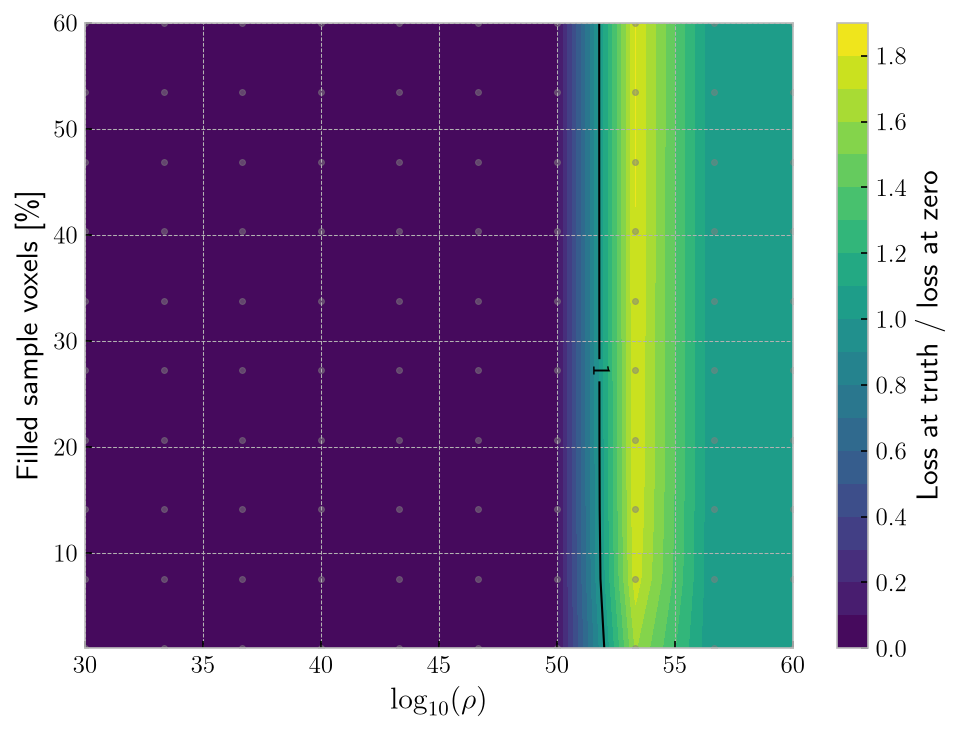

In [364]:
fig, ax = plt.subplots(dpi=150)
contours = ax.contourf(
    np.log10(occupancy_rho_grid), occupancy_grid,
    occupancy_ratio_grid,
    levels=20, cmap="viridis",
)
if occupancy_ratio_grid.min() < 1 < occupancy_ratio_grid.max():
    boundary = ax.contour(
        np.log10(occupancy_rho_grid), occupancy_grid, occupancy_ratio_grid,
        levels=[1], colors="black", linewidths=1,
    )
    ax.clabel(boundary, fmt="%g")
sampled_x, sampled_y = np.meshgrid(np.log10(occupancy_rho_grid), occupancy_grid)
ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)

ax.set_xlabel(r"$\log_{10}(\rho)$")
ax.set_ylabel("Filled sample voxels [\\%]")
fig.colorbar(contours, ax=ax, label="Loss at truth / loss at zero")
fig.savefig("rho_sampleoccupancy.png", bbox_inches="tight")
plt.show()


In [365]:
def random_beads_at_fixed_occupancy(num_beads, rng, target_percent=50, tolerance_percent=0.25):
    """Scale randomly sized spheres together to reach a fixed union occupancy."""
    sample_xs, sample_ys = grid.get_xy()
    centers = np.column_stack([
        rng.uniform(sample_xs.min(), sample_xs.max(), num_beads),
        rng.uniform(sample_ys.min(), sample_ys.max(), num_beads),
        rng.uniform(z_sample_levels.min(), z_sample_levels.max(), num_beads),
    ])
    if num_beads == 1:
        centers[0] = 0.0  # Match the centered single-bead baseline.
    relative_radii = rng.uniform(0.5, 1.5, num_beads)
    # The upper bound lets every bead cover the sample's full diagonal.
    lower_scale = 0.0
    upper_scale = np.linalg.norm([
        np.ptp(sample_xs), np.ptp(sample_ys), np.ptp(z_sample_levels),
    ]) / relative_radii.min()
    best_error = np.inf
    for iteration in range(40):
        scale = (lower_scale + upper_scale) / 2
        radii = scale * relative_radii
        sample = psf.bead_img_3D(
            grid=grid, z_levels=z_sample_levels,
            xs=centers[:, 0], ys=centers[:, 1], zs=centers[:, 2], bead_sizes=radii,
        )
        truth = sample.image_mask
        actual_percent = 100 * np.count_nonzero(truth) / truth.size
        error = abs(actual_percent - target_percent)
        if error < best_error:
            best_error = error
            best = (sample, centers.copy(), radii.copy(), actual_percent)
        if error <= tolerance_percent:
            return best
        if actual_percent < target_percent:
            lower_scale = scale
        else:
            upper_scale = scale
    raise RuntimeError(f"Could not reach {target_percent}% occupancy within tolerance.")


# Fixed 50% filled voxels; vary bead count with random centers and unequal radii.
# Overlaps count once. Average random geometries; reuse each sample for all rho.
bead_count_pattern_rng = np.random.default_rng(0)
bead_count_sample_rng = np.random.default_rng(3)
bead_count_aberration = zernike.RMSAberration(
    modes=modes,
    raw_strengths=bead_count_pattern_rng.normal(0, 1, len(modes)),
    RMS_desired=0.1,
    alpha=microscope.alpha,
)
bead_count_grid = np.array([1, 2, 3, 5, 8, 12, 20, 30, 50, 80])
bead_count_rho_grid = np.logspace(30, 60, 10)
bead_count_trials = 3
bead_count_target_percent = 50.0
bead_count_trial_ratios = np.empty(
    (len(bead_count_grid), len(bead_count_rho_grid), bead_count_trials)
)
bead_count_actual_percent = np.empty((len(bead_count_grid), bead_count_trials))
bead_count_samples = []
bead_count_parameters = []

with tqdm(total=bead_count_trial_ratios.size, desc="Bead count scan at 50% occupancy") as progress:
    for i, num_beads in enumerate(bead_count_grid):
        trial_samples, trial_parameters = [], []
        for trial in range(bead_count_trials):
            sample, centers, radii, actual_percent = random_beads_at_fixed_occupancy(
                num_beads, bead_count_sample_rng, target_percent=bead_count_target_percent,
            )
            bead_count_actual_percent[i, trial] = actual_percent
            trial_samples.append(sample)
            trial_parameters.append(dict(centers=centers, radii=radii))
            bead_count_focal_z, bead_count_diversities, bead_count_clean_images = acquire_diverse_images(
                image=sample,
                aberration=bead_count_aberration,
                focal_z_levels=z_image_levels,
            )
            for j, rho in enumerate(bead_count_rho_grid):
                bead_count_trial_ratios[i, j, trial] = aberration_loss_ratio(
                    grid=grid,
                    images=bead_count_clean_images,
                    focal_z_levels=bead_count_focal_z,
                    diversities=bead_count_diversities,
                    sample_z_levels=z_sample_levels,
                    aberration=bead_count_aberration,
                    rho=rho,
                )
                progress.update(1)
        bead_count_samples.append(trial_samples)
        bead_count_parameters.append(trial_parameters)

bead_count_ratio_grid = bead_count_trial_ratios.mean(axis=2)
bead_count_ratio_std_grid = bead_count_trial_ratios.std(axis=2, ddof=1)


Bead count scan at 50% occupancy: 100%|██████████| 300/300 [10:44<00:00,  2.15s/it]


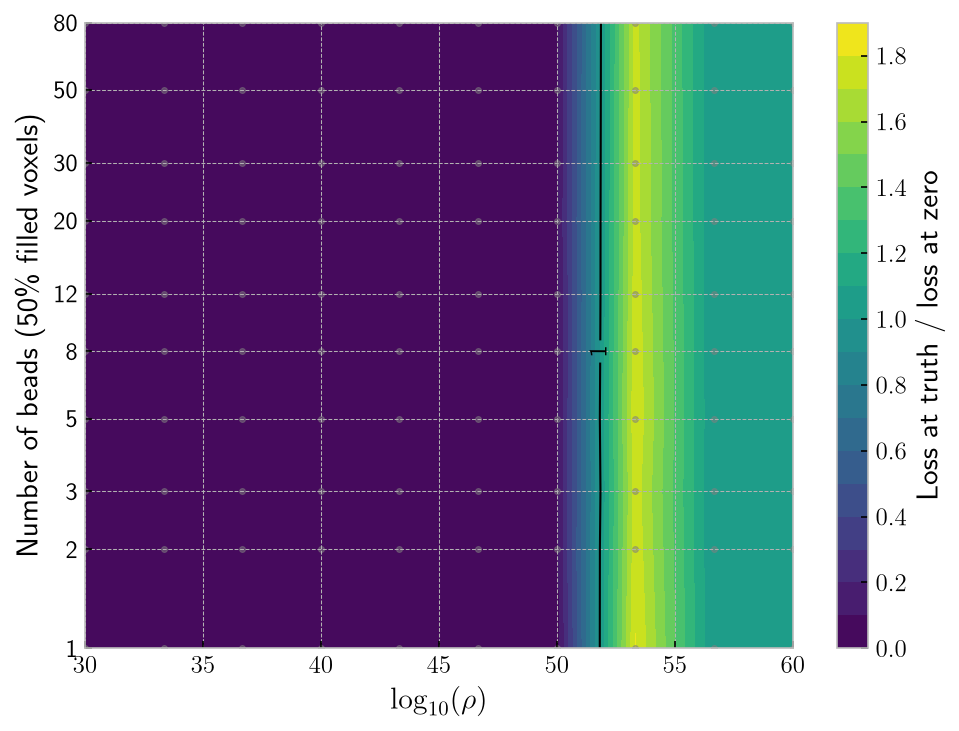

In [366]:
fig, ax = plt.subplots(dpi=150)
contours = ax.contourf(
    np.log10(bead_count_rho_grid), np.log10(bead_count_grid),
    bead_count_ratio_grid,
    levels=20, cmap="viridis",
)
if bead_count_ratio_grid.min() < 1 < bead_count_ratio_grid.max():
    boundary = ax.contour(
        np.log10(bead_count_rho_grid), np.log10(bead_count_grid), bead_count_ratio_grid,
        levels=[1], colors="black", linewidths=1,
    )
    ax.clabel(boundary, fmt="%g")
sampled_x, sampled_y = np.meshgrid(np.log10(bead_count_rho_grid), np.log10(bead_count_grid))
ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)
ax.set_xlabel(r"$\log_{10}(\rho)$")
ax.set_ylabel(r"Number of beads (50\% filled voxels)")
ax.set_yticks(np.log10(bead_count_grid), labels=bead_count_grid)
fig.colorbar(contours, ax=ax, label="Loss at truth / loss at zero")
fig.savefig("rho_beadcount_50percent.png", bbox_inches="tight")
plt.show()


In [367]:
resolution_pattern_rng = np.random.default_rng(0)
resolution_noise_rng = np.random.default_rng(1)
resolution_aberration = zernike.RMSAberration(
    modes=modes,
    raw_strengths=resolution_pattern_rng.normal(0, 1, len(modes)),
    RMS_desired=0.1,
    alpha=microscope.alpha,
)
resolution_grid = np.array([16, 24, 32, 48, 64, 80, 96, 128])
resolution_rho_grid = np.logspace(30, 60, 10)
resolution_ratio_grid = np.empty((len(resolution_grid), len(resolution_rho_grid)))

with tqdm(total=resolution_ratio_grid.size, desc="Image resolution scan") as progress:
    for i, resolution in enumerate(resolution_grid):
        resolution_sample_grid = psf.Centered_Square_Grid(
            L_ffp=L_ffp, grid_ffp=int(resolution), z_level=0,
        )
        resolution_sample = psf.bead_img_3D(
            grid=resolution_sample_grid,
            xs=[0.0], ys=[0.0], zs=[0.0], bead_sizes=[0.001],
            z_levels=z_sample_levels,
        )
        resolution_focal_z, resolution_diversities, resolution_clean_images = acquire_diverse_images(
            image=resolution_sample,
            aberration=resolution_aberration,
            focal_z_levels=z_image_levels,
        )
        resolution_noisy_images = poisson_images_at_snr(
            resolution_clean_images, EXPERIMENT_SNR, resolution_noise_rng,
        )

        for j, rho in enumerate(resolution_rho_grid):
            resolution_ratio_grid[i, j] = aberration_loss_ratio(
                grid=resolution_sample_grid,
                images=resolution_noisy_images,
                focal_z_levels=resolution_focal_z,
                diversities=resolution_diversities,
                sample_z_levels=z_sample_levels,
                aberration=resolution_aberration,
                rho=rho,
            )
            progress.update(1)


Image resolution scan: 100%|██████████| 80/80 [03:23<00:00,  2.55s/it]


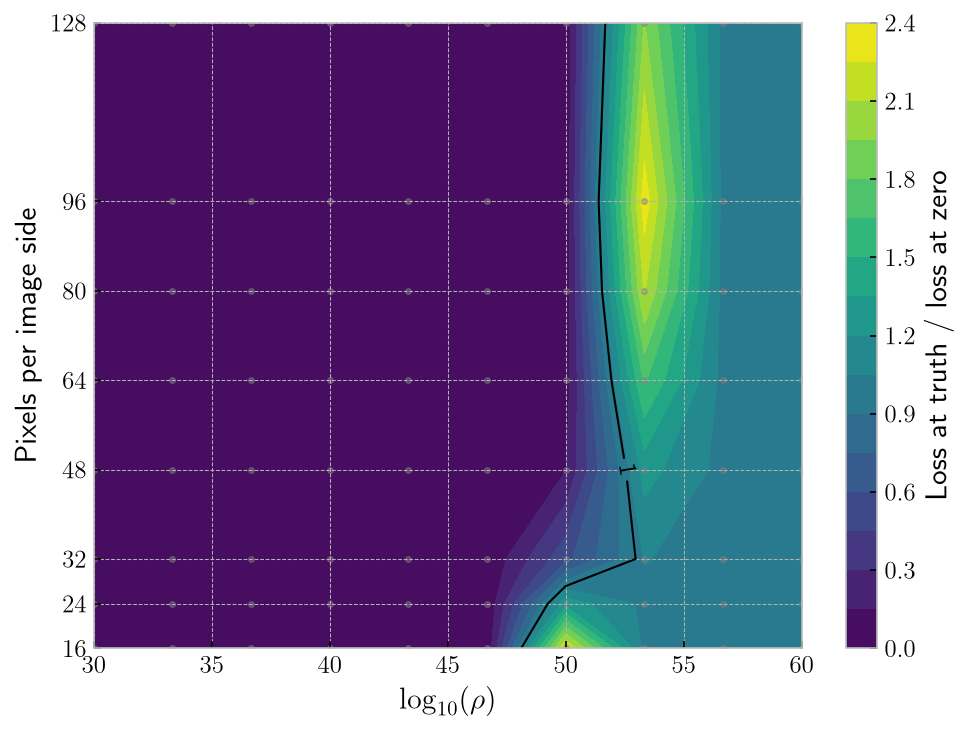

In [368]:
fig, ax = plt.subplots(dpi=150)
contours = ax.contourf(
    np.log10(resolution_rho_grid), resolution_grid,
    resolution_ratio_grid,
    levels=20, cmap="viridis",
)
if resolution_ratio_grid.min() < 1 < resolution_ratio_grid.max():
    boundary = ax.contour(
        np.log10(resolution_rho_grid), resolution_grid, resolution_ratio_grid,
        levels=[1], colors="black", linewidths=1,
    )
    ax.clabel(boundary, fmt="%g")
sampled_x, sampled_y = np.meshgrid(np.log10(resolution_rho_grid), resolution_grid)
ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)

ax.set_xlabel(r"$\log_{10}(\rho)$")
ax.set_ylabel("Pixels per image side")
ax.set_yticks(resolution_grid)
fig.colorbar(contours, ax=ax, label="Loss at truth / loss at zero")
fig.savefig("rho_image_resolution.png", bbox_inches="tight")
plt.show()


In [369]:
mode_count_pattern_rng = np.random.default_rng(0)
mode_count_noise_rng = np.random.default_rng(1)
mode_count_raw_strengths = mode_count_pattern_rng.normal(0, 1, len(modes))
mode_count_grid = np.arange(1, len(modes) + 1)
mode_count_rho_grid = np.logspace(30, 60, 10)
mode_count_rms = 0.1
mode_count_ratio_grid = np.empty((len(mode_count_grid), len(mode_count_rho_grid)))
mode_count_aberrations = []

with tqdm(total=mode_count_ratio_grid.size, desc="Aberration mode count scan") as progress:
    for i, mode_count in enumerate(mode_count_grid):
        # Add modes in list order, retaining relative coefficients at fixed total RMS.
        mode_count_modes = modes[:mode_count]
        mode_count_aberration = zernike.RMSAberration(
            modes=mode_count_modes,
            raw_strengths=mode_count_raw_strengths[:mode_count],
            RMS_desired=mode_count_rms,
            alpha=microscope.alpha,
        )
        mode_count_aberrations.append(mode_count_aberration)
        mode_count_focal_z, mode_count_diversities, mode_count_clean_images = acquire_diverse_images(
            image=mask_3D,
            aberration=mode_count_aberration,
            focal_z_levels=z_image_levels,
        )
        mode_count_noisy_images = poisson_images_at_snr(
            mode_count_clean_images, EXPERIMENT_SNR, mode_count_noise_rng,
        )

        for j, rho in enumerate(mode_count_rho_grid):
            mode_count_ratio_grid[i, j] = aberration_loss_ratio(
                grid=grid,
                images=mode_count_noisy_images,
                focal_z_levels=mode_count_focal_z,
                diversities=mode_count_diversities,
                sample_z_levels=z_sample_levels,
                aberration=mode_count_aberration,
                rho=rho,
            )
            progress.update(1)


Aberration mode count scan: 100%|██████████| 170/170 [05:57<00:00,  2.10s/it]


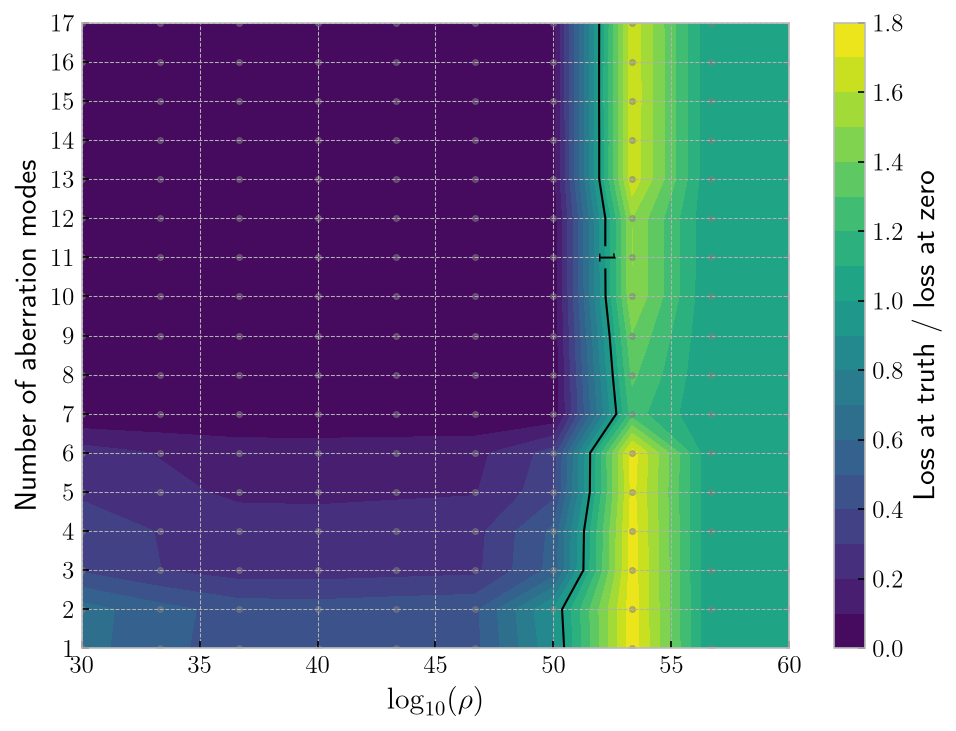

In [370]:
fig, ax = plt.subplots(dpi=150)
contours = ax.contourf(
    np.log10(mode_count_rho_grid), mode_count_grid, mode_count_ratio_grid,
    levels=20, cmap="viridis",
)
if mode_count_ratio_grid.min() < 1 < mode_count_ratio_grid.max():
    boundary = ax.contour(
        np.log10(mode_count_rho_grid), mode_count_grid, mode_count_ratio_grid,
        levels=[1], colors="black", linewidths=1,
    )
    ax.clabel(boundary, fmt="%g")
sampled_x, sampled_y = np.meshgrid(np.log10(mode_count_rho_grid), mode_count_grid)
ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)
ax.set_xlabel(r"$\log_{10}(\rho)$")
ax.set_ylabel("Number of aberration modes")
ax.set_yticks(mode_count_grid)
fig.colorbar(contours, ax=ax, label="Loss at truth / loss at zero")
fig.savefig("rho_aberration_modes.png", bbox_inches="tight")
plt.show()


In [371]:
diversity_count_pattern_rng = np.random.default_rng(0)
diversity_count_noise_rng = np.random.default_rng(1)
diversity_count_aberration = zernike.RMSAberration(
    modes=modes,
    raw_strengths=diversity_count_pattern_rng.normal(0, 1, len(modes)),
    RMS_desired=0.1,
    alpha=microscope.alpha,
)
diversity_count_grid = np.arange(1, 11)
diversity_count_rho_grid = np.logspace(30, 60, 10)
diversity_count_strength_limit = 0.10
diversity_count_ratio_grid = np.empty(
    (len(diversity_count_grid), len(diversity_count_rho_grid))
)
diversity_count_strengths = []
diversity_count_total_images = len(z_image_levels) * diversity_count_grid

with tqdm(total=diversity_count_ratio_grid.size, desc="Spherical diversity count scan") as progress:
    for i, diversity_count in enumerate(diversity_count_grid):
        # One frame is the zero-diversity baseline; otherwise include both endpoints.
        strengths = (
            np.array([0.0]) if diversity_count == 1
            else np.linspace(-diversity_count_strength_limit,
                             diversity_count_strength_limit, diversity_count)
        )
        diversity_count_strengths.append(strengths)
        diversity_count_focal_z, diversity_count_diversities, diversity_count_clean_images = acquire_diverse_images(
            image=mask_3D,
            aberration=diversity_count_aberration,
            focal_z_levels=z_image_levels,
            diversity_strengths=strengths,
            diversity_mode=[0, 4],
        )
        diversity_count_noisy_images = poisson_images_at_snr(
            diversity_count_clean_images, EXPERIMENT_SNR, diversity_count_noise_rng,
        )

        for j, rho in enumerate(diversity_count_rho_grid):
            diversity_count_ratio_grid[i, j] = aberration_loss_ratio(
                grid=grid,
                images=diversity_count_noisy_images,
                focal_z_levels=diversity_count_focal_z,
                diversities=diversity_count_diversities,
                sample_z_levels=z_sample_levels,
                aberration=diversity_count_aberration,
                rho=rho,
            )
            progress.update(1)


Spherical diversity count scan: 100%|██████████| 100/100 [07:04<00:00,  4.24s/it]


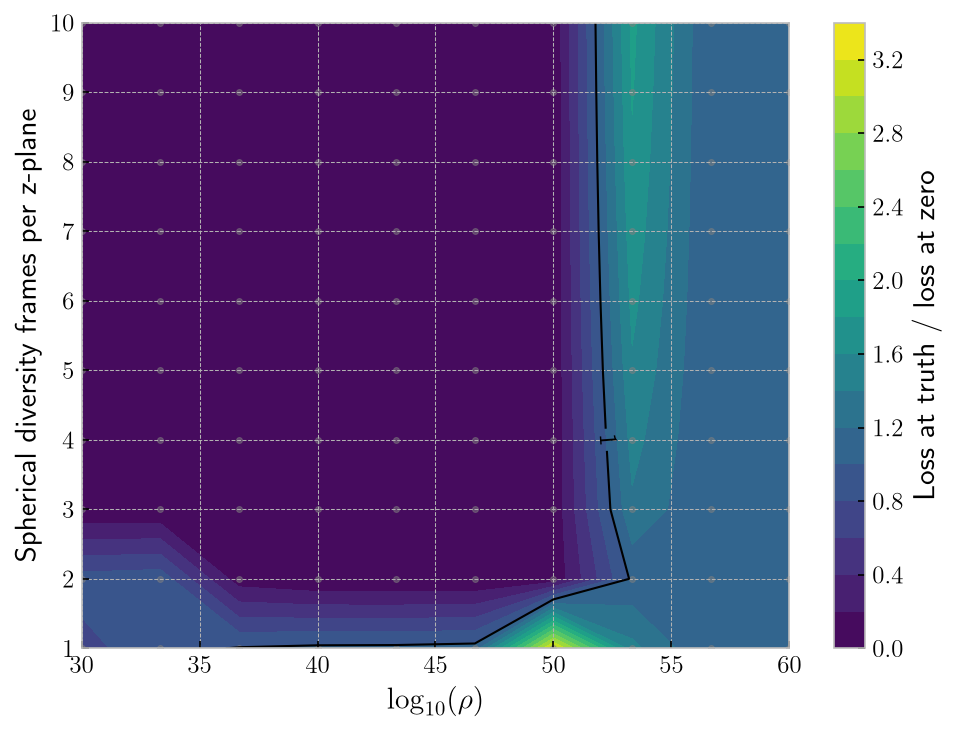

In [372]:
fig, ax = plt.subplots(dpi=150)
contours = ax.contourf(
    np.log10(diversity_count_rho_grid), diversity_count_grid,
    diversity_count_ratio_grid,
    levels=20, cmap="viridis",
)
if diversity_count_ratio_grid.min() < 1 < diversity_count_ratio_grid.max():
    boundary = ax.contour(
        np.log10(diversity_count_rho_grid), diversity_count_grid,
        diversity_count_ratio_grid,
        levels=[1], colors="black", linewidths=1,
    )
    ax.clabel(boundary, fmt="%g")
sampled_x, sampled_y = np.meshgrid(
    np.log10(diversity_count_rho_grid), diversity_count_grid,
)
ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)

ax.set_xlabel(r"$\log_{10}(\rho)$")
ax.set_ylabel("Spherical diversity frames per z-plane")
ax.set_yticks(diversity_count_grid)
fig.colorbar(contours, ax=ax, label="Loss at truth / loss at zero")
fig.savefig("rho_diversity_count.png", bbox_inches="tight")
plt.show()


In [373]:
# One random aberration shape per trial, shared across all modes, RMS values, and SNRs.
diversity_mode_rho = 1e46
diversity_mode_strengths = np.array([-0.10, 0.0, 0.10])  # Coefficients in waves.
diversity_mode_rms_grid = np.linspace(0, 0.50, 10)
diversity_mode_snr_grid = np.logspace(0, 2.5, 20)
diversity_mode_pattern_seed = 0
diversity_mode_noise_seed = 1
diversity_mode_num_trials = 5
diversity_mode_cases = [
    ("Spherical (0, 4)", [0, 4]),
    ("Astigmatism (-2, 2)", [-2, 2]),
    ("Astigmatism (2, 2)", [2, 2]),
    ("Coma (-1, 3)", [-1, 3]),
    ("Coma (1, 3)", [1, 3]),
    ("Trefoil (-3, 3)", [-3, 3]),
    ("Trefoil (3, 3)", [3, 3]),
]
diversity_mode_pattern_rng = np.random.default_rng(diversity_mode_pattern_seed)
diversity_mode_raw_strengths = diversity_mode_pattern_rng.normal(
    0, 1, size=(diversity_mode_num_trials, len(modes)),
)
# Axes: trial, diversity mode, aberration RMS, SNR.
diversity_mode_trial_ratios = np.empty((
    diversity_mode_num_trials,
    len(diversity_mode_cases),
    len(diversity_mode_rms_grid),
    len(diversity_mode_snr_grid),
))

with tqdm(total=diversity_mode_trial_ratios.size, desc="Diversity mode / RMS / SNR scan") as progress:
    for trial, raw_strengths in enumerate(diversity_mode_raw_strengths):
        diversity_mode_aberrations = [
            zernike.RMSAberration(
                modes=modes,
                raw_strengths=raw_strengths,
                RMS_desired=rms,
                alpha=microscope.alpha,
            )
            for rms in diversity_mode_rms_grid
        ]

        for i, (label, diversity_mode) in enumerate(diversity_mode_cases):
            for j, diversity_mode_aberration in enumerate(diversity_mode_aberrations):
                diversity_mode_focal_z, diversity_mode_diversities, diversity_mode_clean_images = acquire_diverse_images(
                    image=mask_3D,
                    aberration=diversity_mode_aberration,
                    focal_z_levels=z_image_levels,
                    diversity_strengths=diversity_mode_strengths,
                    diversity_mode=diversity_mode,
                )
                for k, snr in enumerate(diversity_mode_snr_grid):
                    diversity_mode_noise_rng = np.random.default_rng(
                        np.random.SeedSequence([diversity_mode_noise_seed, trial, i, j, k])
                    )
                    diversity_mode_noisy_images = poisson_images_at_snr(
                        diversity_mode_clean_images, snr, diversity_mode_noise_rng,
                    )
                    # Evaluate two profiled losses; initial means zero unknown aberration.
                    diversity_mode_trial_ratios[trial, i, j, k] = aberration_loss_ratio(
                        grid=grid,
                        images=diversity_mode_noisy_images,
                        focal_z_levels=diversity_mode_focal_z,
                        diversities=diversity_mode_diversities,
                        sample_z_levels=z_sample_levels,
                        aberration=diversity_mode_aberration,
                        rho=diversity_mode_rho,
                    )
                    progress.update(1)

# Plot the mean of the per-trial ratios; retain their spread separately.
diversity_mode_ratio_grid = diversity_mode_trial_ratios.mean(axis=0)
diversity_mode_ratio_std = diversity_mode_trial_ratios.std(axis=0)


Diversity mode / RMS / SNR scan: 100%|██████████| 7000/7000 [3:59:46<00:00,  2.06s/it]  


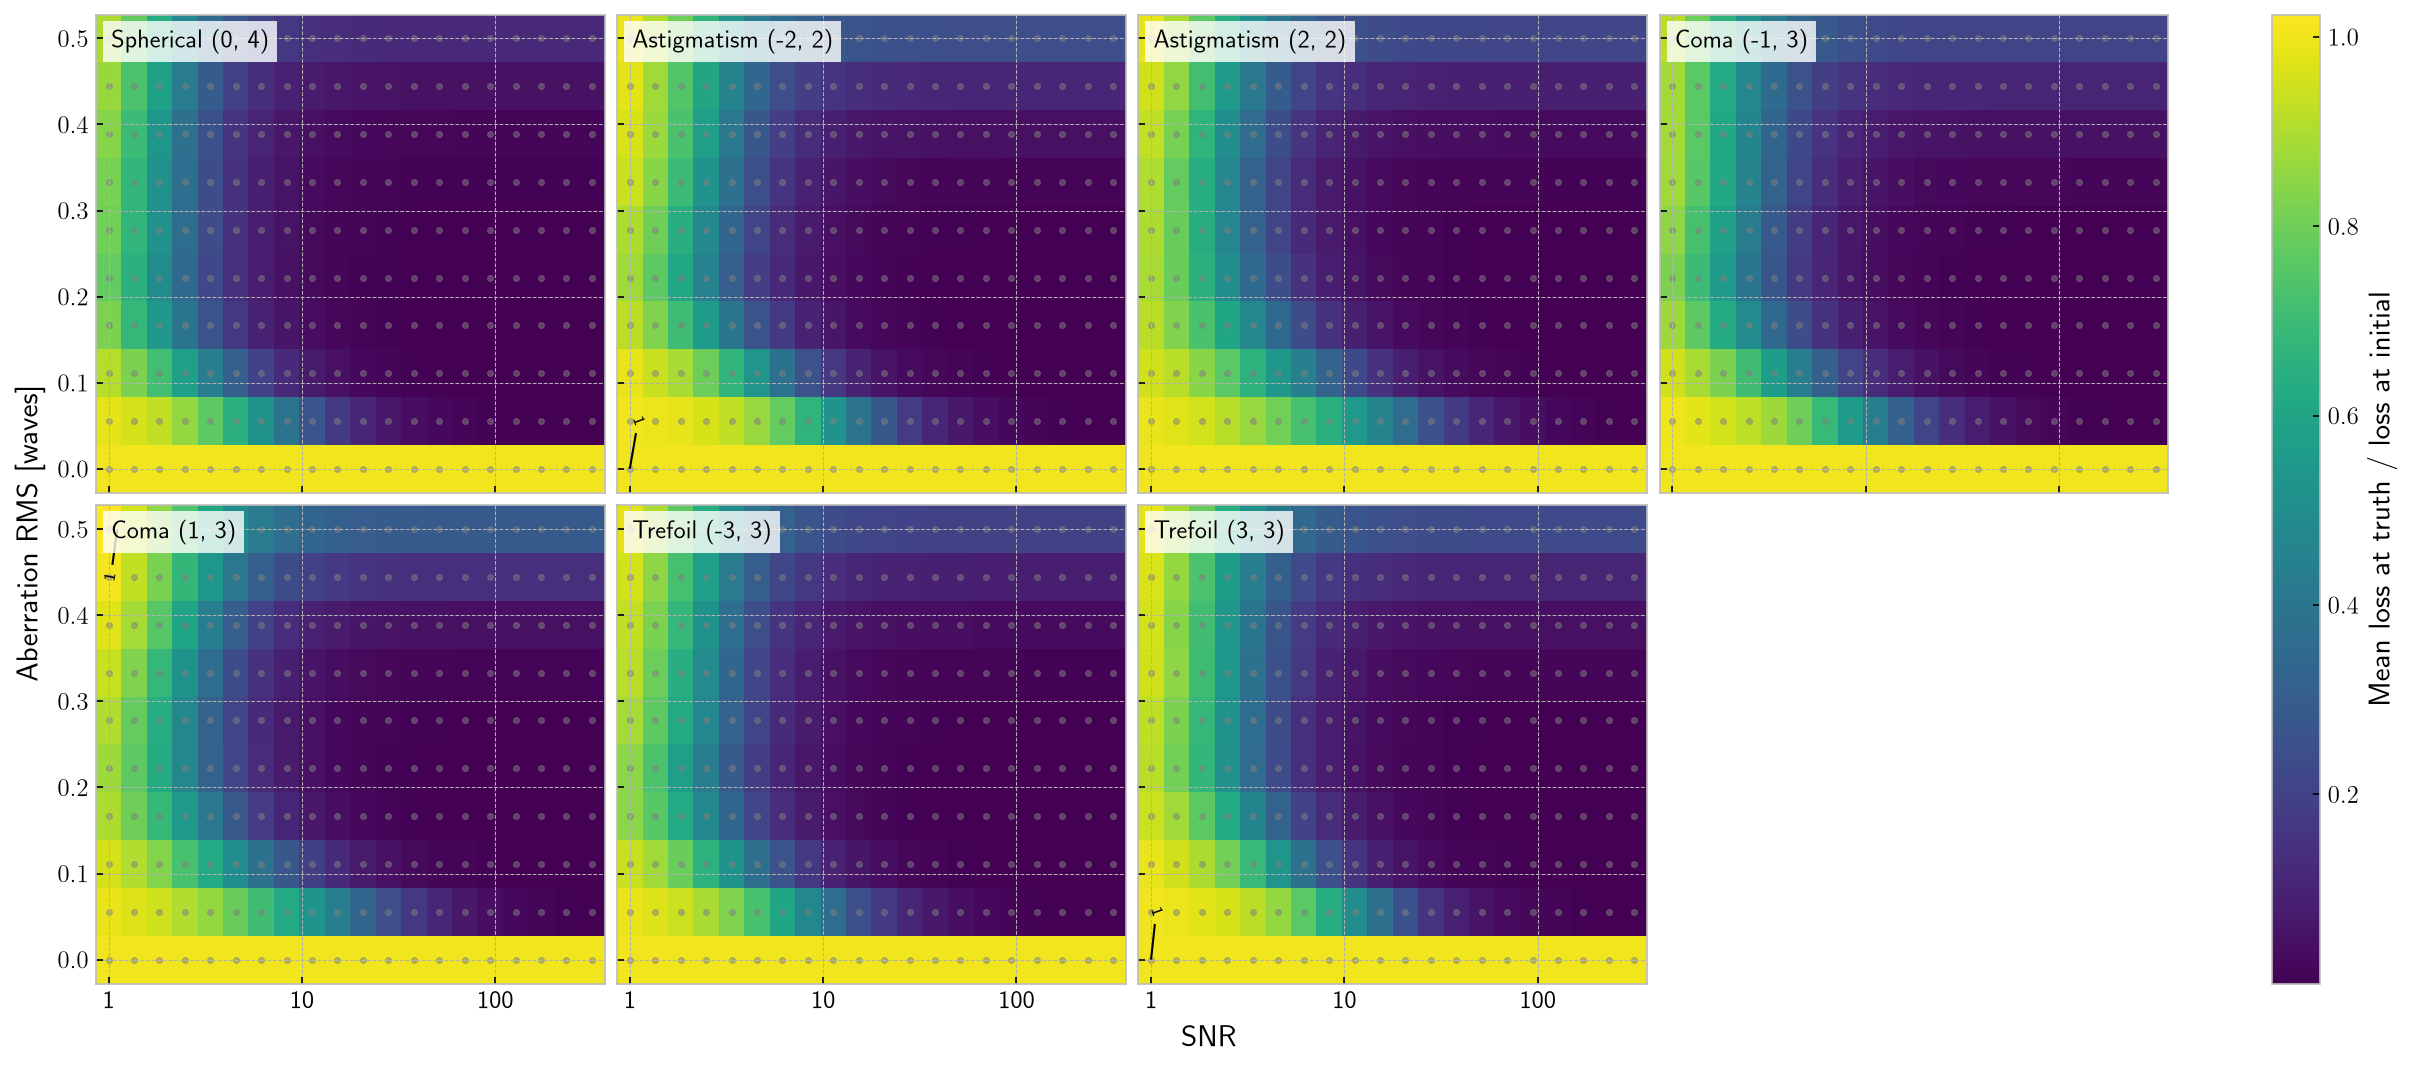

In [374]:
diversity_mode_ncols = min(4, len(diversity_mode_cases))
diversity_mode_nrows = (len(diversity_mode_cases) + diversity_mode_ncols - 1) // diversity_mode_ncols
fig, axs = plt.subplots(
    diversity_mode_nrows, diversity_mode_ncols,
    figsize=(4 * diversity_mode_ncols, 3.5 * diversity_mode_nrows),
    dpi=150, sharex=True, sharey=True, squeeze=False, layout="constrained",
)
diversity_mode_norm = plt.Normalize(
    vmin=diversity_mode_ratio_grid.min(), vmax=diversity_mode_ratio_grid.max(),
)
diversity_mode_log_snr = np.log10(diversity_mode_snr_grid)
diversity_mode_snr_ticks = np.arange(
    np.ceil(diversity_mode_log_snr.min()), np.floor(diversity_mode_log_snr.max()) + 1,
)
sampled_x, sampled_y = np.meshgrid(diversity_mode_log_snr, diversity_mode_rms_grid)
for i, ((label, _), ax) in enumerate(zip(diversity_mode_cases, axs.flat)):
    heatmap = ax.pcolormesh(
        diversity_mode_log_snr, diversity_mode_rms_grid, diversity_mode_ratio_grid[i],
        shading="nearest", cmap="viridis", norm=diversity_mode_norm,
    )
    ratios = diversity_mode_ratio_grid[i]
    if ratios.min() < 1 < ratios.max():
        boundary = ax.contour(
            diversity_mode_log_snr, diversity_mode_rms_grid, ratios,
            levels=[1], colors="black", linewidths=1,
        )
        ax.clabel(boundary, fmt="%g", fontsize=8)
    ax.scatter(sampled_x.ravel(), sampled_y.ravel(), s=8, c="gray", alpha=0.5)
    ax.set_xticks(diversity_mode_snr_ticks, labels=[f"{10**tick:g}" for tick in diversity_mode_snr_ticks])
    ax.text(
        0.03, 0.97, label, transform=ax.transAxes, va="top",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )
for ax in axs.flat[len(diversity_mode_cases):]:
    fig.delaxes(ax)
fig.supxlabel("SNR")
fig.supylabel("Aberration RMS [waves]")
fig.colorbar(
    heatmap, ax=list(axs.flat[:len(diversity_mode_cases)]),
    label="Mean loss at truth / loss at initial",
)
fig.savefig("diversity_mode_snr_aberration_rms.png", bbox_inches="tight")
plt.show()
